In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("data/data.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
print(df['EmployeeCount'].unique())
print(df['Over18'].unique())
print(df['StandardHours'].unique())

[1]
['Y']
[80]


In [13]:
#Since they have the same values throughout, drop them
columns_to_drop = ['StandardHours', 'Over18', 'EmployeeCount', 'EmployeeNumber']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


In [14]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany               int64
YearsInCurrentRole  

--- Missing Values ---
Series([], dtype: int64)

Number of MonthlyIncome outliers detected: 114


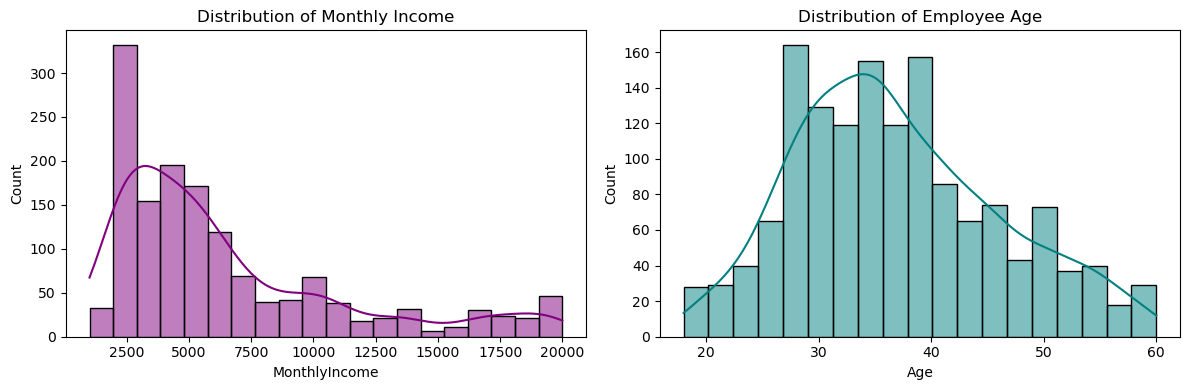

In [15]:
# Missing Values Check
print("--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Should be empty for this dataset

# Outlier Detection using Interquartile Range (IQR) for MonthlyIncome
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['MonthlyIncome'] < (Q1 - 1.5 * IQR)) | (df['MonthlyIncome'] > (Q3 + 1.5 * IQR))]
print(f"\nNumber of MonthlyIncome outliers detected: {len(outliers)}")

# Distribution Visualization of Key Numerical Features
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['MonthlyIncome'], kde=True, color='purple')
plt.title('Distribution of Monthly Income')

plt.subplot(1, 2, 2)
sns.histplot(df['Age'], kde=True, color='teal')
plt.title('Distribution of Employee Age')
plt.tight_layout()
plt.show()

In [16]:
#Statistical Testing:
import scipy.stats as stats

# Chi-Square Test of Independence: Attrition vs. OverTime
contingency_table = pd.crosstab(df['OverTime'], df['Attrition'])
chi2, p_val, dof, ex = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Test (OverTime vs Attrition): Chi2 = {chi2:.2f}, p-value = {p_val:.5e}")

# Independent T-Test: MonthlyIncome vs. Attrition
income_stayed = df[df['Attrition'] == 0]['MonthlyIncome']
income_left = df[df['Attrition'] == 1]['MonthlyIncome']
t_stat, p_val_t = stats.ttest_ind(income_stayed, income_left, equal_var=False)
print(f"Independent T-Test (MonthlyIncome vs Attrition): t-stat = {t_stat:.2f}, p-value = {p_val_t:.5e}")

Chi-Square Test (OverTime vs Attrition): Chi2 = 87.56, p-value = 8.15842e-21
Independent T-Test (MonthlyIncome vs Attrition): t-stat = nan, p-value = nan


c:\Users\Ananta\anaconda3\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [17]:
#Detailed Analytics & Categorical Breakdowns
df_analytics = pd.read_csv(r"D:\attrition\data\data.csv")

# Attrition Rate by Job Role (%)
print("--- Attrition Rate by Job Role ---")
role_attr = df_analytics.groupby('JobRole')['Attrition'].agg(
    Total_Employees='count',
    Attrited_Employees=lambda x: (x == 'Yes').sum(),
    Attrition_Rate=lambda x: (x == 'Yes').mean() * 100
).sort_values(by='Attrition_Rate', ascending=False)
print(role_attr.round(2))

#  Attrition Rate by Job Satisfaction Level
print("\n--- Attrition Rate by Job Satisfaction Level ---")
# Map text to numeric if needed, or use raw data columns
sat_attr = df_analytics.groupby('JobSatisfaction')['Attrition'].agg(
    Attrition_Rate=lambda x: (x == 'Yes').mean() * 100
)
print(sat_attr.round(2))

# Attrition Rate by Tenure Group
df_analytics['Tenure_Group'] = pd.cut(
    df_analytics['YearsAtCompany'], 
    bins=[-1, 2, 5, 10, 40], 
    labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs']
)
print("\n--- Attrition Rate by Tenure Group ---")
tenure_attr = df_analytics.groupby('Tenure_Group', observed=False)['Attrition'].agg(
    Attrition_Rate=lambda x: (x == 'Yes').mean() * 100
)
print(tenure_attr.round(2))

--- Attrition Rate by Job Role ---
                           Total_Employees  Attrited_Employees  Attrition_Rate
JobRole                                                                       
Sales Representative                    83                  33           39.76
Laboratory Technician                  259                  62           23.94
Human Resources                         52                  12           23.08
Sales Executive                        326                  57           17.48
Research Scientist                     292                  47           16.10
Manufacturing Director                 145                  10            6.90
Healthcare Representative              131                   9            6.87
Manager                                102                   5            4.90
Research Director                       80                   2            2.50

--- Attrition Rate by Job Satisfaction Level ---
                 Attrition_Rate
JobSatisfactio

Attrition
No     1233
Yes     237
Name: count, dtype: int64


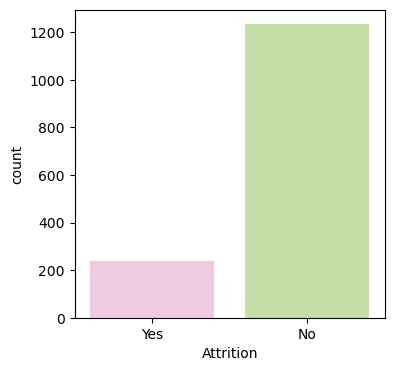

In [18]:
#First, let us check the total number of people who've left.
plt.figure(figsize=(4,4))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette='PiYG')

print(df['Attrition'].value_counts())
plt.show()

In [19]:
# Convert Attrition and OverTime into 1s and 0s
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# For Gender, let's map Male to 1 and Female to 0 
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [20]:
travel_mapping = {'Non-Travel' : 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['BusinessTravel'] = df['BusinessTravel'].map(travel_mapping)

In [21]:
# List the columns that don't have an inherent numerical order
nominal_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']

# This will automatically drop the old text columns and create the new 1/0 columns
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [22]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
print(df.dtypes)

Age                                  int64
Attrition                            int64
BusinessTravel                       int64
DailyRate                            int64
DistanceFromHome                     int64
Education                            int64
EnvironmentSatisfaction              int64
Gender                               int64
HourlyRate                           int64
JobInvolvement                       int64
JobLevel                             int64
JobSatisfaction                      int64
MonthlyIncome                        int64
MonthlyRate                          int64
NumCompaniesWorked                   int64
OverTime                             int64
PercentSalaryHike                    int64
PerformanceRating                    int64
RelationshipSatisfaction             int64
StockOptionLevel                     int64
TotalWorkingYears                    int64
TrainingTimesLastYear                int64
WorkLifeBalance                      int64
YearsAtComp

In [23]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102,1,2,2,0,94,3,...,0,0,0,0,0,0,1,0,0,1
1,49,0,2,279,8,1,3,1,61,2,...,0,0,0,0,0,1,0,0,1,0
2,37,1,1,1373,2,2,4,1,92,2,...,0,1,0,0,0,0,0,0,0,1
3,33,0,2,1392,3,4,4,0,56,3,...,0,0,0,0,0,1,0,0,1,0
4,27,0,1,591,2,1,1,1,40,3,...,0,1,0,0,0,0,0,0,1,0


Total Counts:
Attrition
0    1233
1     237
Name: count, dtype: int64

Percentages:
Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


C:\Users\Ananta\AppData\Local\Temp\ipykernel_7452\3995009662.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette="Set2")


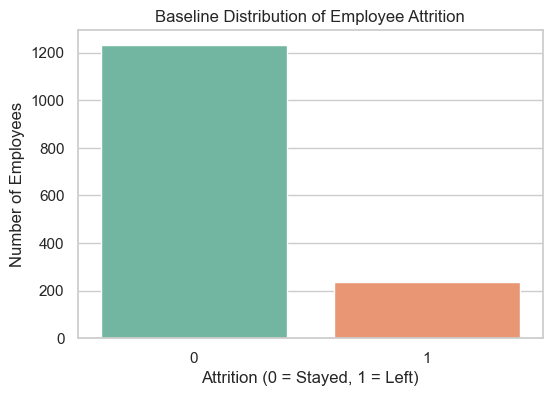

In [24]:
sns.set_theme(style="whitegrid")

# 1. Calculate baseline percentages
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print(f"Total Counts:\n{attrition_counts}\n")
print(f"Percentages:\n{attrition_pct}")

# 2. Plot the baseline
plt.figure(figsize=(6, 4))
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette="Set2")
plt.title('Baseline Distribution of Employee Attrition')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Employees')
plt.show()

C:\Users\Ananta\AppData\Local\Temp\ipykernel_7452\2412680036.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df, x='OverTime', y='Attrition', errorbar=None, palette='ocean' )
C:\Users\Ananta\AppData\Local\Temp\ipykernel_7452\2412680036.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Overtime (0)', 'Works Overtime (1)'])
C:\Users\Ananta\AppData\Local\Temp\ipykernel_7452\2412680036.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df, x='BusinessTravel', y='Attrition', errorbar=None, palette='magma')
C:\Users\Ananta\AppData\Local\Temp\i

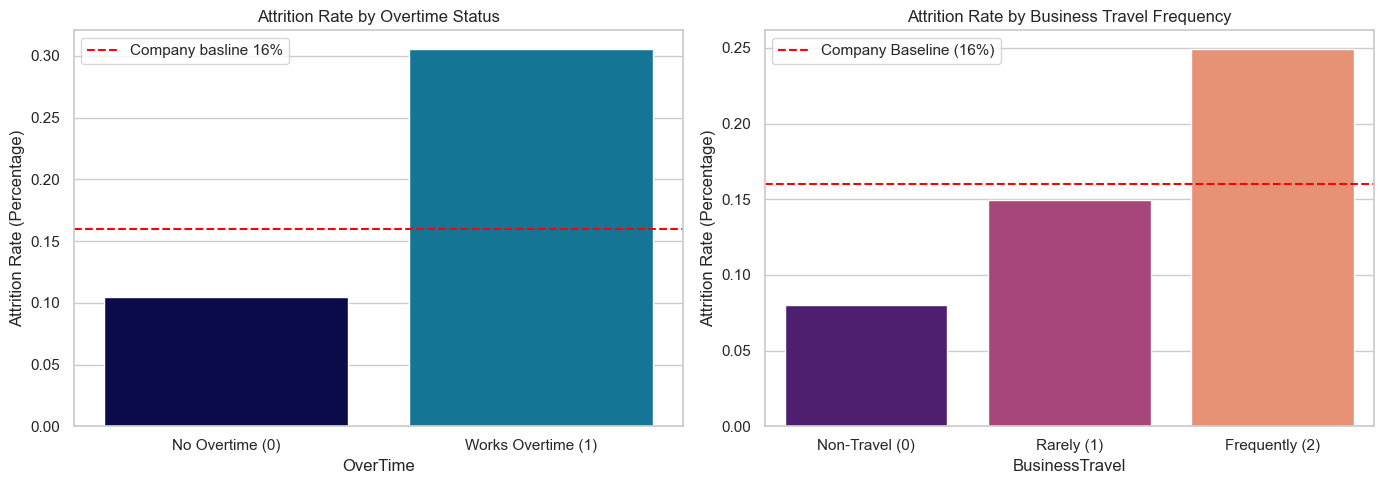

In [25]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
#Overtime V/S Attrition
sns.barplot(ax=axes[0], data=df, x='OverTime', y='Attrition', errorbar=None, palette='ocean' )
axes[0].axhline(y = 0.16, color='red', linestyle='--', label='Company basline 16%')
axes[0].set_title('Attrition Rate by Overtime Status')
axes[0].set_ylabel('Attrition Rate (Percentage)')
axes[0].set_xticklabels(['No Overtime (0)', 'Works Overtime (1)'])
axes[0].legend()
#Business Travel V/S Attrition
sns.barplot(ax=axes[1], data=df, x='BusinessTravel', y='Attrition', errorbar=None, palette='magma')
axes[1].axhline(y=0.16, color='red', linestyle='--', label='Company Baseline (16%)')
axes[1].set_title('Attrition Rate by Business Travel Frequency')
axes[1].set_ylabel('Attrition Rate (Percentage)')
axes[1].set_xticklabels(['Non-Travel (0)', 'Rarely (1)', 'Frequently (2)'])
axes[1].legend()
plt.tight_layout()
plt.show()

C:\Users\Ananta\AppData\Local\Temp\ipykernel_7452\4235615040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='Attrition', y='MonthlyIncome', palette="Set2")
C:\Users\Ananta\AppData\Local\Temp\ipykernel_7452\4235615040.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Stayed (0)', 'Left (1)'])


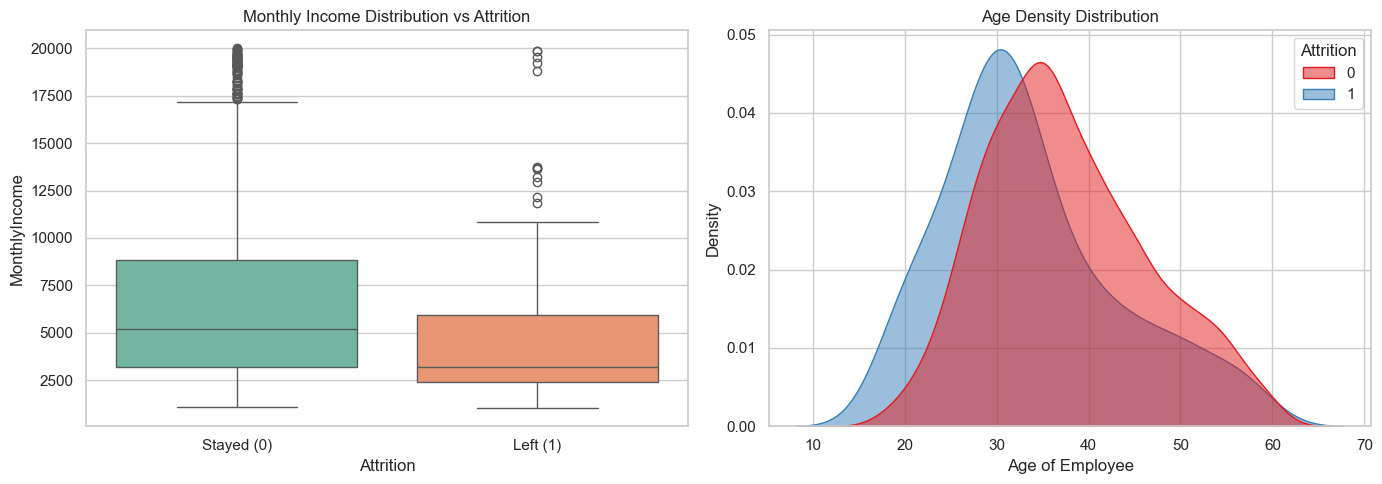

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income and attrtition
sns.boxplot(ax=axes[0], data=df, x='Attrition', y='MonthlyIncome', palette="Set2")
axes[0].set_title('Monthly Income Distribution vs Attrition')
axes[0].set_xticklabels(['Stayed (0)', 'Left (1)'])

# Age vs Attrition
sns.kdeplot(ax=axes[1], data=df, x='Age', hue='Attrition', fill=True, common_norm=False, palette="Set1", alpha=0.5)
axes[1].set_title('Age Density Distribution')
axes[1].set_xlabel('Age of Employee')


plt.tight_layout()
plt.show()

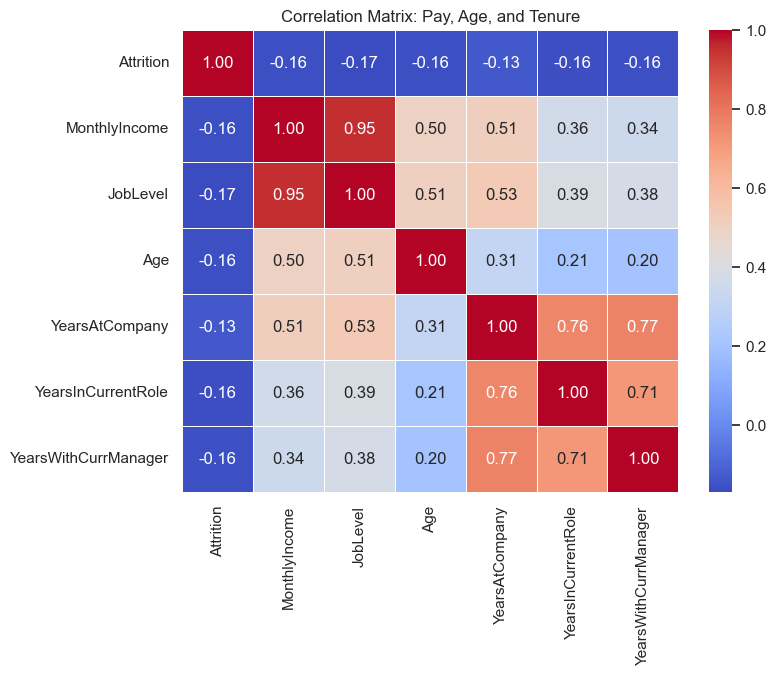

In [27]:
# Checking correlation
time_and_pay_features = [
    'Attrition', 'MonthlyIncome', 'JobLevel', 'Age', 
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager'
]

# Correlation matrix
corr_matrix = df[time_and_pay_features].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Pay, Age, and Tenure')
plt.show()

What We've observed so far:
- About 16% of the employees left.
- Those working overtime have an attrition rate of 30%, almost doublr the company baseline(16%). Overtime is likely causing employee burnout, and is a primary reason employees are leaving.
- Employees who travel more have a higher chance of leaving, compared to those who do not travel at all.
- Most people who leave the company make under $6,000 a month, with the average runner making only around $3,200. On the other hand, employees making high salaries ($15,000+) almost never quit.
- Younger employees have a higher chance of leaving.
- Our correlation heatmap showed that 'JobLevel' and 'MonthlyIncome' are almost perfectly tied together (close to 1.0). We also found that all the time-based metrics (like 'YearsAtCompany' , 'YearsWithCurrManager', 'YearsInCurrentRole') are heavily overlapping.
- Higher income, higher job levels, and longer tenure all correlate with lower attrition (people staying).


In [28]:
X = df.drop(columns=['Attrition', 'JobLevel'])
y = df['Attrition']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
from sklearn.preprocessing import StandardScaler

num_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears', 
            'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager']


scaler = StandardScaler()

X_train_scaled = x_train.copy()
X_test_scaled = x_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(x_test[num_cols])

In [30]:
print(X_train_scaled[num_cols].head())

           Age  MonthlyIncome  DistanceFromHome  TotalWorkingYears  \
1194  1.090194       2.026752         -0.899915           2.261482   
128  -1.634828      -0.864408         -0.899915          -1.072675   
810   0.981193       2.347706         -0.777610           1.492061   
478  -1.307825      -0.956202          0.445433          -0.559727   
491   0.654191      -0.185956         -0.043784          -0.175017   

      YearsAtCompany  YearsInCurrentRole  YearsWithCurrManager  
1194       -0.665706           -0.625365             -0.616406  
128        -0.830071           -0.905635             -0.897047  
810         0.813578            1.336527              1.348076  
478        -0.008246           -0.064824              0.506155  
491         0.156119            0.775986              0.786795  


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
# We are using Logistic Regression, Random Forest, and XGBoost
# Calculate the imbalance ratio for XGBoost
# Total negative cases (0) divided by total positive cases (1)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
xgb_model = xgb.XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')


In [32]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"================ {name} ================")
    print(f"Overall Accuracy : {acc:.2%}")
    print(f"Recall (Catching flight risks) : {rec:.2%}")
    print(f"F1-Score (Overall balance)     : {f1:.2%}")
    print("\nDetailed Report:")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))
    print("\n")

c:\Users\Ananta\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


================ Logistic Regression ================
Overall Accuracy : 77.55%
Recall (Catching flight risks) : 70.21%
F1-Score (Overall balance)     : 50.00%

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.86       247
        Left       0.39      0.70      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.78      0.80       294



================ Random Forest ================
Overall Accuracy : 84.35%
Recall (Catching flight risks) : 8.51%
F1-Score (Overall balance)     : 14.81%

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.99      0.91       247
        Left       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       

### **Model Evaluation & Final Selection Conclusions**

We trained three distinct classification models (Logistic Regression, Random Forest, and XGBoost) to predict employee attrition. Because our dataset is highly imbalanced (~16% attrition baseline), we look beyond standard **Accuracy** and prioritize **Recall** and **Precision**. 

| Model | Accuracy | Recall (Caught Flight Risks) | Precision (True Signals) | F1-Score (Balance) |
| :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | 77.55% | **70.21%** 🏆 | 39.00% | **50.00%** 🏆 |
| **Random Forest** | 84.35% | 8.51% | 57.00% | 14.81% |
| **XGBoost** | **86.39%** | 36.17% | **62.96%** 🏆 | 45.95% |

#### **Key Insights & Trade-offs:**

1. **The Core Business Problem (Why Recall is King):** In an HR retention scenario, the cost of a *False Negative* (missing an employee who is secretly planning to leave) is incredibly high—they walk out the door and the company loses talent. The cost of a *False Positive* (wrongly flagging a happy employee) is incredibly low—HR simply schedules a routine check-in conversation. Therefore, we must maximize **Recall**.

2. **Logistic Regression is the Winner:**
   * **Why:** By using balanced class weights, Logistic Regression successfully captured **70.21% of all actual flight risks** (33 out of 47 runners). 
   * **Trade-off:** It is somewhat paranoid, yielding a lower Precision (39.00%), meaning it triggers several false alarms. However, as a wide safety net, it is our most effective tool.

3. **Why the Tree Models Underperformed:**
   * **Random Forest** completely failed to find the target population (8.51% Recall). It prioritized overall accuracy by simply guessing "Stayed" for almost everyone.
   * **XGBoost** proved to be highly calculated and precise (62.96% Precision), but it missed too many actual runners (only 36.17% Recall). 

#### **Final Decision:**
We select **Logistic Regression** as our production baseline model because it provides the company with the highest capability to catch and intervene with high-risk employees before they quit.

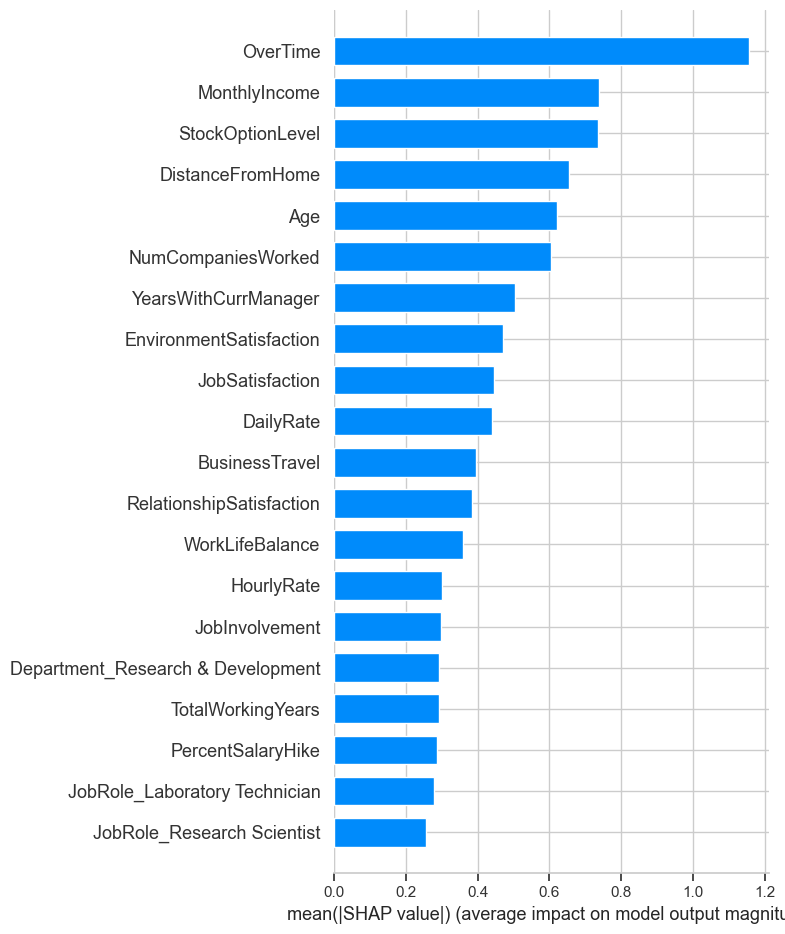

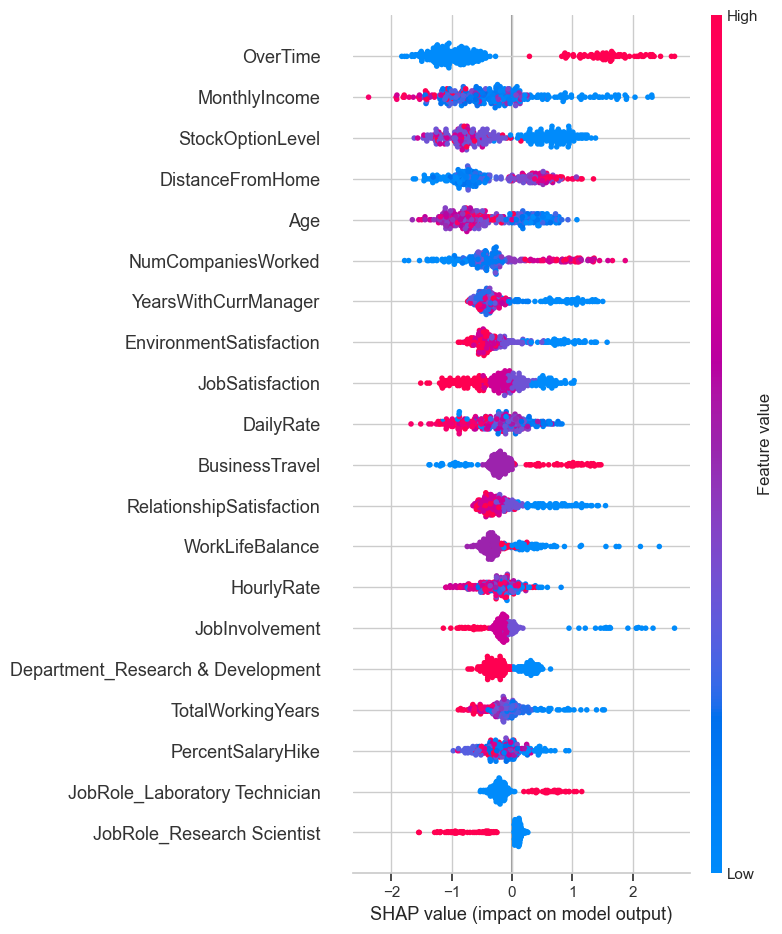

In [39]:
import shap

# Initialize SHAP explainer using your trained XGBoost model 
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for your test dataset
shap_values = explainer.shap_values(X_test_scaled)

# 1. Feature Importance Summary Bar Plot
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar")

# 2. Detailed Beehive/Dot Plot
shap.summary_plot(shap_values, X_test_scaled)

In [33]:
import joblib

#Saving the trained model and scaler to files
joblib.dump(log_reg, 'attrition_model.pkl')
joblib.dump(scaler, 'numerical_scaler.pkl')


['numerical_scaler.pkl']